# 03. Modeling — Credit Card Fraud Detection

**Project:** Fraud Detection & AI Governance Portfolio
**Goal:** Train and compare four models, then move beyond the default 0.5 cutoff with **threshold tuning** and a **cost-sensitive analysis** that turns the precision/recall trade-off into a dollars decision.

---

### What we do
1. Four models: **LogReg (balanced)**, **LogReg + SMOTE**, **Random Forest**, **XGBoost**
2. Score them all with imbalance-aware metrics (PR-AUC is the headline)
3. **Threshold tuning** — the 0.5 cutoff is rarely optimal for rare events
4. **Cost-sensitive analysis** — pick the operating point that minimizes total business cost (missed fraud vs false alarms)
5. Save models + the chosen threshold for evaluation/governance

> **Why not accuracy?** Fraud is 0.17%. "Always normal" scores 99.83% accuracy and catches zero fraud. We judge by **Recall** (fraud caught), **Precision** (alerts that are real), **F1**, and **PR-AUC**.

## 0. Setup + load the processed data

**What:** Import tools and load the leakage-free splits from notebook 02.
**Why:** Reusing the saved splits keeps modeling consistent with preprocessing.

In [1]:
import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Metrics
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve,
)

import matplotlib.pyplot as plt
import joblib
from pathlib import Path

print("Libraries imported ✅")

Libraries imported ✅


In [2]:
# Load the processed splits saved by notebook 02.
data_dir = Path("../data/processed")
X_train = pd.read_csv(data_dir / "X_train.csv")
X_test = pd.read_csv(data_dir / "X_test.csv")
y_train = pd.read_csv(data_dir / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(data_dir / "y_test.csv").squeeze("columns")

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Fraud in train:", int(y_train.sum()), " | Fraud in test:", int(y_test.sum()))

X_train: (227845, 30)  X_test: (56962, 30)
Fraud in train: 394  | Fraud in test: 98


## 1. A reusable evaluation function

**What:** One helper that scores a trained model on the test set and records the metrics.
**Why:** Four models, one consistent scoreboard. We also stash each model's fraud probabilities so the threshold/cost analysis can reuse them without recomputing.

In [3]:
# Running scoreboard + a place to cache each model's predicted fraud probabilities.
results = []
proba_cache = {}

def evaluate(name, model):
    # predict(): hard 0/1 decision at the default 0.5 threshold.
    y_pred = model.predict(X_test)
    # predict_proba()[:, 1]: probability of fraud (class 1). AUC metrics use this.
    y_proba = model.predict_proba(X_test)[:, 1]
    proba_cache[name] = y_proba  # cache for later threshold tuning

    scores = {
        "model": name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }
    results.append(scores)

    print(f"=== {name} ===")
    for k, v in scores.items():
        if k != "model":
            print(f"  {k:10s}: {v:.4f}")
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}  (FN = fraud we missed)")
    return scores

## 2. Model 1 — Logistic Regression (class_weight="balanced")

**What:** A linear baseline that handles imbalance by **re-weighting** the loss so each rare fraud counts as much as the crowd of normals.
**Why first?** Fast and interpretable. If a complex model can't beat this, the complexity isn't worth it.

In [4]:
# class_weight="balanced": weight classes inversely to frequency. max_iter=1000: enough iterations to converge.
logreg = LogisticRegression(class_weight="balanced", max_iter=1000)
logreg.fit(X_train, y_train)
_ = evaluate("LogReg (balanced)", logreg)

=== LogReg (balanced) ===
  precision : 0.0610
  recall    : 0.9184
  f1        : 0.1144
  roc_auc   : 0.9722
  pr_auc    : 0.7159
  TN=55478  FP=1386  FN=8  TP=90  (FN = fraud we missed)


## 3. Model 2 — SMOTE + Logistic Regression

**What:** SMOTE invents synthetic fraud rows (by interpolating between real ones) until classes balance, then we train a plain LogReg.
**Why:** A different anti-imbalance lever — re-balance the *data* instead of re-weighting the loss.

> **Leakage guard:** SMOTE touches the **training set only**. The test set stays real and untouched.

In [5]:
# Generate synthetic fraud rows so train becomes ~50/50. random_state=42 for reproducibility.
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After  SMOTE:", y_train_sm.value_counts().to_dict())

logreg_smote = LogisticRegression(max_iter=1000)
logreg_smote.fit(X_train_sm, y_train_sm)
_ = evaluate("LogReg + SMOTE", logreg_smote)

Before SMOTE: {0: 227451, 1: 394}
After  SMOTE: {0: 227451, 1: 227451}


=== LogReg + SMOTE ===
  precision : 0.0580
  recall    : 0.9184
  f1        : 0.1092
  roc_auc   : 0.9699
  pr_auc    : 0.7249
  TN=55403  FP=1461  FN=8  TP=90  (FN = fraud we missed)


## 4. Model 3 — Random Forest (class_weight="balanced")

**What:** An ensemble of 100 decision trees that vote. Captures non-linear feature interactions.
**Why:** Fraud signals are often non-linear. RF usually lifts PR-AUC and gives feature importances we reuse in governance.

In [6]:
# 100 trees, balanced weights, all CPU cores, reproducible.
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
_ = evaluate("Random Forest", rf)

=== Random Forest ===
  precision : 0.9167
  recall    : 0.7857
  f1        : 0.8462
  roc_auc   : 0.9573
  pr_auc    : 0.8626
  TN=56857  FP=7  FN=21  TP=77  (FN = fraud we missed)


## 5. Model 4 — XGBoost (gradient boosting)

**What:** Gradient-boosted trees — builds trees sequentially, each fixing the previous ones' mistakes. Often the top performer on tabular data.
**Why:** A strong contender, and its probabilities tend to be well-calibrated for threshold tuning. We handle imbalance with `scale_pos_weight` (how much extra weight each fraud gets).

In [7]:
# scale_pos_weight = (#normal / #fraud) in train -> tells XGBoost how rare fraud is.
neg, pos = int((y_train == 0).sum()), int((y_train == 1).sum())
spw = neg / pos
print(f"scale_pos_weight = {neg} / {pos} = {spw:.1f}")

# eval_metric="aucpr": optimize toward PR-AUC. n_jobs=-1, reproducible.
xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    scale_pos_weight=spw, eval_metric="aucpr",
    n_jobs=-1, random_state=42,
)
xgb.fit(X_train, y_train)
_ = evaluate("XGBoost", xgb)

scale_pos_weight = 227451 / 394 = 577.3


=== XGBoost ===
  precision : 0.8283
  recall    : 0.8367
  f1        : 0.8325
  roc_auc   : 0.9873
  pr_auc    : 0.8659
  TN=56847  FP=17  FN=16  TP=82  (FN = fraud we missed)


## 6. Compare all models

**What:** One table, sorted by PR-AUC (our headline metric).
**Why:** The trade-offs — especially **precision vs recall** — become obvious side by side.

In [8]:
comparison = pd.DataFrame(results).set_index("model").sort_values("pr_auc", ascending=False)
comparison.round(4)

,precision,recall,f1,roc_auc,pr_auc
model,,,,,
XGBoost,0.8283,0.8367,0.8325,0.9873,0.8659
Random Forest,0.9167,0.7857,0.8462,0.9573,0.8626
LogReg + SMOTE,0.0580,0.9184,0.1092,0.9699,0.7249
LogReg (balanced),0.0610,0.9184,0.1144,0.9722,0.7159


In [9]:
# Save the comparison and remember the best model name (top PR-AUC) for the steps below.
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)
comparison.round(4).to_csv(results_dir / "model_comparison.csv")

best_name = comparison.index[0]
models = {"LogReg (balanced)": logreg, "LogReg + SMOTE": logreg_smote,
          "Random Forest": rf, "XGBoost": xgb}
best_model = models[best_name]
print("Best model by PR-AUC:", best_name)

Best model by PR-AUC: XGBoost


### Interpretation
- **XGBoost / Random Forest** lead on **PR-AUC** — they catch fraud with far fewer false alarms than the linear models.
- The **balanced / SMOTE logistic regressions** reach high **recall** but low **precision** (many false alerts) — aggressive flaggers.
- Core fraud tension: **higher recall usually costs precision.** Which to favor is a *risk/business* decision — quantified next.

## 7. Threshold tuning — the 0.5 cutoff is rarely optimal

**What:** A classifier outputs a probability; turning it into a 0/1 decision needs a **threshold**. The default 0.5 is arbitrary for rare events. We sweep thresholds on the best model and watch precision, recall, and F1 move.
**Why:** Lowering the threshold catches more fraud (↑recall) but raises false alarms (↓precision). Choosing the threshold *is* choosing the operating point of the whole system.

Max-F1 threshold = 0.9100  -> precision=0.910, recall=0.827, F1=0.866


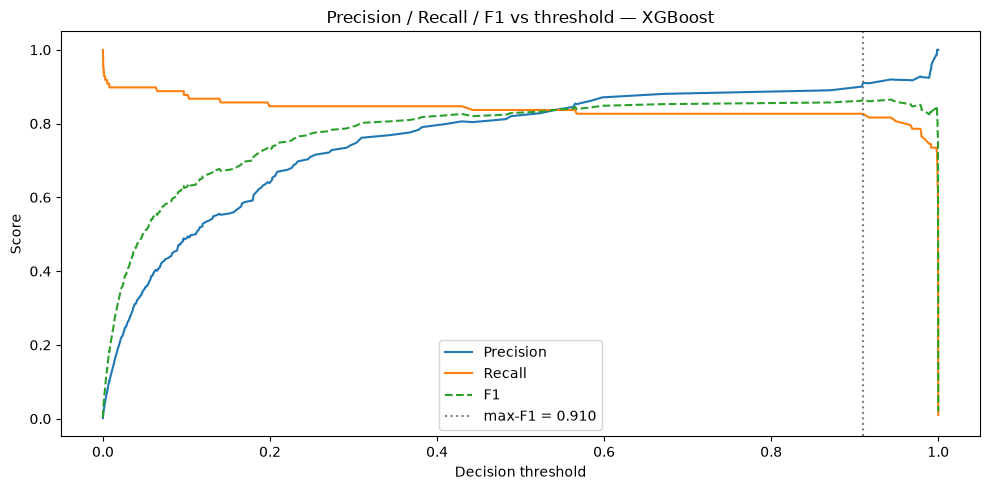

In [10]:
# Use the best model's cached fraud probabilities.
proba = proba_cache[best_name]

# precision_recall_curve returns precision/recall at every candidate threshold.
prec, rec, thr = precision_recall_curve(y_test, proba)
# prec/rec have one more entry than thr; align by dropping the last prec/rec point.
prec, rec = prec[:-1], rec[:-1]
# F1 at each threshold (small epsilon avoids divide-by-zero).
f1 = 2 * prec * rec / (prec + rec + 1e-9)

# Threshold that maximizes F1.
best_f1_idx = f1.argmax()
print(f"Max-F1 threshold = {thr[best_f1_idx]:.4f}  -> precision={prec[best_f1_idx]:.3f}, recall={rec[best_f1_idx]:.3f}, F1={f1[best_f1_idx]:.3f}")

# Plot precision / recall / F1 vs threshold.
plt.figure(figsize=(10, 5))
plt.plot(thr, prec, label="Precision")
plt.plot(thr, rec, label="Recall")
plt.plot(thr, f1, label="F1", linestyle="--")
plt.axvline(thr[best_f1_idx], color="gray", linestyle=":", label=f"max-F1 = {thr[best_f1_idx]:.3f}")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title(f"Precision / Recall / F1 vs threshold — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Cost-sensitive analysis ⭐ — turning the trade-off into dollars

**What:** F1 treats precision and recall as equally important. In fraud, they are **not**: a missed fraud (False Negative) and a false alarm (False Positive) cost very different amounts. We attach a dollar cost to each error type and pick the threshold that **minimizes total cost**.
**Why:** This is the bridge from a model metric to a business/risk decision — the heart of an AI Risk Analyst's job. The chosen threshold becomes a documented, defensible policy.

**Cost assumptions (illustrative — these are *business inputs*, not model outputs):**
- **`COST_FN` = \$200** — average loss when a fraud slips through undetected
- **`COST_FP` = \$5** — cost to manually review a false alarm

In production these numbers come from finance/ops, and the whole analysis is re-run when they change.

Cost-minimizing threshold = 0.060  -> total cost = $2,675
(For comparison, total cost at the default 0.50 threshold = $3,285)


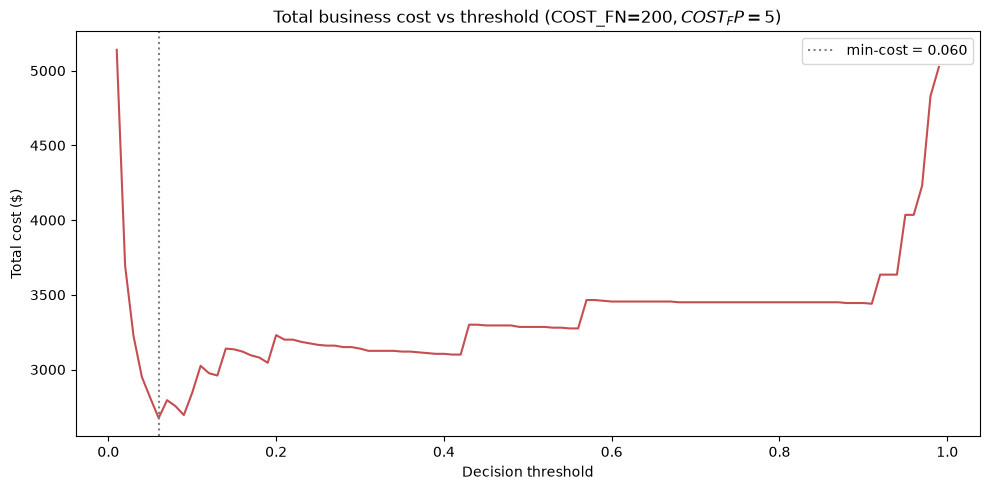

In [11]:
# Business cost inputs (illustrative). Change these and the optimal threshold moves.
COST_FN = 200.0   # cost of one missed fraud
COST_FP = 5.0     # cost of one false alarm (manual review)

# Sweep candidate thresholds and compute total cost at each.
candidate_thr = np.linspace(0.01, 0.99, 99)
total_costs = []
for t in candidate_thr:
    pred = (proba >= t).astype(int)          # flag fraud if probability >= threshold
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    cost = fn * COST_FN + fp * COST_FP       # missed-fraud cost + false-alarm cost
    total_costs.append(cost)
total_costs = np.array(total_costs)

# Cost-minimizing threshold.
best_cost_idx = total_costs.argmin()
chosen_threshold = float(candidate_thr[best_cost_idx])
print(f"Cost-minimizing threshold = {chosen_threshold:.3f}  -> total cost = ${total_costs[best_cost_idx]:,.0f}")
print(f"(For comparison, total cost at the default 0.50 threshold = ${total_costs[np.argmin(np.abs(candidate_thr-0.5))]:,.0f})")

# Plot total cost vs threshold.
plt.figure(figsize=(10, 5))
plt.plot(candidate_thr, total_costs, color="#C44E52")
plt.axvline(chosen_threshold, color="gray", linestyle=":", label=f"min-cost = {chosen_threshold:.3f}")
plt.xlabel("Decision threshold")
plt.ylabel("Total cost ($)")
plt.title(f"Total business cost vs threshold (COST_FN=${COST_FN:.0f}, COST_FP=${COST_FP:.0f})")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Show the confusion matrix at the chosen (cost-optimal) threshold vs the default 0.5.
for label, t in [("default 0.50", 0.5), (f"cost-optimal {chosen_threshold:.3f}", chosen_threshold)]:
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"[{label}]  caught fraud TP={tp}/{tp+fn}  missed FN={fn}  false alarms FP={fp}")

[default 0.50]  caught fraud TP=82/98  missed FN=16  false alarms FP=17
[cost-optimal 0.060]  caught fraud TP=88/98  missed FN=10  false alarms FP=135


### Interpretation
- Because a missed fraud (\$200) costs far more than a false alarm (\$5), the cost-optimal threshold sits **well below 0.5** — the system should flag aggressively.
- Moving off 0.5 to the cost-optimal point **catches more fraud at lower total cost**, even though raw precision drops.
- **Governance takeaway:** the threshold is not a technical default — it is a **risk-appetite policy** set by the business cost ratio, and it must be documented and reviewed when those costs change.

## 9. Save models + the chosen operating point

**What:** Persist all four models, plus the chosen threshold and cost assumptions.
**Why:** Notebook 04 evaluates at this exact threshold; 05 explains this exact model. Saving guarantees the downstream notebooks analyze the same artifacts.

In [13]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(logreg, models_dir / "logreg_balanced.joblib")
joblib.dump(logreg_smote, models_dir / "logreg_smote.joblib")
joblib.dump(rf, models_dir / "random_forest.joblib")
joblib.dump(xgb, models_dir / "xgboost.joblib")

# Save the chosen operating point + which model is primary, as JSON for the next notebooks.
import json as _json
decision = {
    "best_model": best_name,
    "chosen_threshold": chosen_threshold,
    "cost_fn": COST_FN,
    "cost_fp": COST_FP,
}
(results_dir / "decision.json").write_text(_json.dumps(decision, indent=2))
print("Saved models and decision.json")
print(decision)

Saved models and decision.json
{'best_model': 'XGBoost', 'chosen_threshold': 0.060000000000000005, 'cost_fn': 200.0, 'cost_fp': 5.0}


## 10. Summary

| Model | Imbalance strategy | Character |
|-------|--------------------|-----------|
| LogReg (balanced) | re-weight loss | high recall, low precision |
| LogReg + SMOTE | synthetic resampling | aggressive flagging |
| Random Forest | re-weight loss | strong PR-AUC, few false alarms |
| XGBoost | scale_pos_weight | usually best PR-AUC; well-calibrated |

**Decisions carried forward:** primary model = best by PR-AUC; operating threshold = **cost-minimizing** point (not 0.5).

> **Documented knobs (governance):** model family, `class_weight`/SMOTE/`scale_pos_weight`, the cost ratio (FN:FP), and the resulting threshold. Each changes *who gets flagged*.

---

### Next Step — 04_Evaluation
1. Load the best model + chosen threshold
2. Confusion matrix, **PR curve**, ROC curve at the operating point
3. **Fairness audit** across Amount ranges and time-of-day segments
4. **Error analysis** — what kind of fraud does the model still miss?